## **Genomics Lab**

Olivia Pang

In [ ]:
! git clone https://github.com/ds4e/undergrad_ml_assignments

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 110, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 110 (delta 37), reused 18 (delta 18), pack-reused 62 (from 1)
Receiving objects: 100% (110/110), 11.76 MiB | 7.61 MiB/s, done.
Resolving deltas: 100% (46/46), done.


Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health?

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

1. Load the golub.csv dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

In [ ]:
# 1
df = pd.read_csv('/content/undergrad_ml_assignments/data/golub.csv')
df.head()

,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,48,BM,F,DFCI,BM:f,allB,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876


In [ ]:
mapper = {'allB':0, 'allT': 0, 'aml':1}
df['y'] = df['cancer'].map(mapper)
df['y']

,y
0,0
1,0
2,0
3,0
4,0
...,...
67,1
68,1
69,1
70,1


2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

In [ ]:
# 2
df.columns.to_list()
genes = df.drop(['Samples',
 'BM.PB',
 'Gender',
 'Source',
 'tissue.mf',
 'cancer', 'y'], axis = 1)
y = df['y']

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
model  = LinearRegression()
model = model.fit(genes, y)
y_hat = model.predict(genes)
resid = y_hat-y
print(resid.describe())

mse = mean_squared_error(y, y_hat)
print(mse)

count    7.200000e+01
mean    -5.396917e-17
std      1.125596e-15
min     -2.553513e-15
25%     -7.494005e-16
50%      0.000000e+00
75%      5.828671e-16
max      2.220446e-15
Name: y, dtype: float64
1.2522824482837894e-30


The mean squared error is 1.2522824482837894e-30, which is essentially 0.

<Axes: xlabel='y', ylabel='Density'>

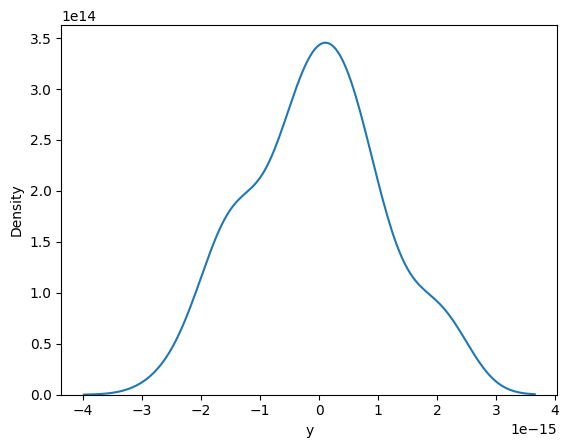

In [ ]:
sns.kdeplot(resid)

Text(0.5, 1.0, 'Linear Regression Predictions vs. True Values')

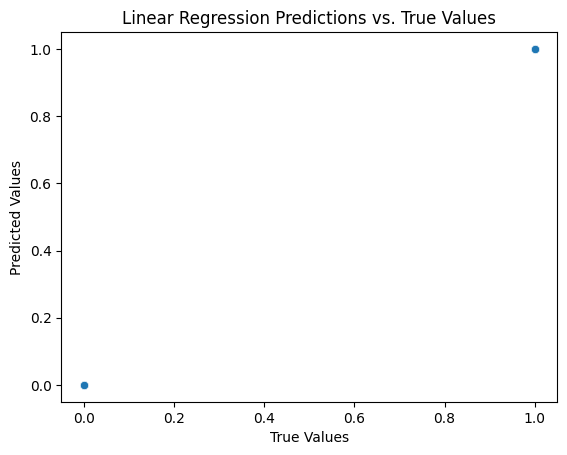

In [ ]:
sns.scatterplot(x = y, y = y_hat)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Linear Regression Predictions vs. True Values')

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(n_splits=10, shuffle=True, random_state=100) # Create folds
model = LinearRegression()

scores = -cross_val_score(model, genes, y, cv = kfold, scoring= 'neg_mean_squared_error')

print("Fold scores:", scores)
print("Mean score:", np.mean(scores))
print("Median score:", np.median(scores))
print("Std dev:", np.std(scores))

Fold scores: [0.02265367 0.04875751 0.06347474 0.06304086 0.09383082 0.08300696
 0.0207161  0.01969831 0.02087605 0.02271393]
Mean score: 0.045876895088525556
Median score: 0.03573571993995745
Std dev: 0.027037144984588028


The mean cross validated MSE is 0.0459. The jump in MSE from 0 to 0.0459 indicates that the model is likely overfitting. When
it was faced with "new" data during the k-fold validation its predictions were worse. Models that overfit tend to have high
variability in their predictions. In this case, that means the model could predict different outcomes with even a small change
in the gene input. Though variability is high for such a model as this, bias will be low (hence bias variance trade-off). This
means the predictions will not dramatically skew one way or the other.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

gene_names = genes.columns

scaler = StandardScaler()
genes_sc = scaler.fit_transform(genes)

lasso = LassoCV(cv=10, random_state=100, max_iter=10000)
lasso.fit(genes_sc, y)

coef = lasso.coef_

selected_genes = []
for i in coef:
  if i!= 0:
    index = list(coef).index(i)
    selected_genes.append(gene_names[index])
discarded_count = len(gene_names) - len(selected_genes)

print(f"Optimal Alpha: {lasso.alpha_: }")
print(f"Number of selected genes: {len(selected_genes)}")
print(f"Number of discarded genes: {discarded_count}")
print(selected_genes)

Optimal Alpha:  0.0006701743064744867
Number of selected genes: 81
Number of discarded genes: 7048
['AF000560_at', 'AF002020_at', 'AF006087_at', 'D26579_at', 'D29956_at', 'D42043_at', 'D50840_at', 'D86982_at', 'HG2161-HT2231_at', 'J04101_at', 'J04164_at', 'L12723_at', 'L13848_at', 'L20941_at', 'M12759_at', 'M17754_at', 'M19507_at', 'M20902_at', 'M22960_at', 'M23197_at', 'M27891_at', 'M28713_at', 'M31994_at', 'M34344_at', 'M63138_at', 'M84526_at', 'M95178_at', 'M96326_rna1_at', 'M98539_at', 'U10868_at', 'U14588_at', 'U30828_at', 'U34877_at', 'U36621_cds2_at', 'U46751_at', 'U50136_rna1_at', 'U51127_at', 'U60062_at', 'U82313_at', 'U82759_at', 'U88666_at', 'U89942_at', 'X04143_at', 'X14789_at', 'X16706_at', 'X53331_at', 'X56741_at', 'X63753_at', 'X66533_at', 'X66867_cds1_at', 'X69111_at', 'X81479_at', 'X83378_at', 'X95735_at', 'X96698_at', 'Y00636_at', 'Y07604_at', 'Y07755_at', 'Y10207_at', 'Y12670_at', 'M96843_at', 'X58072_at', 'AC002477_s_at', 'L15326_s_at', 'X57351_at', 'K02777_s_at', '

There are 81 selected genes and 7048 discarded genes. The selected genes can be found in the selected genes list above.

Text(0.5, 1.0, 'LASSO Predictions vs. True Values')

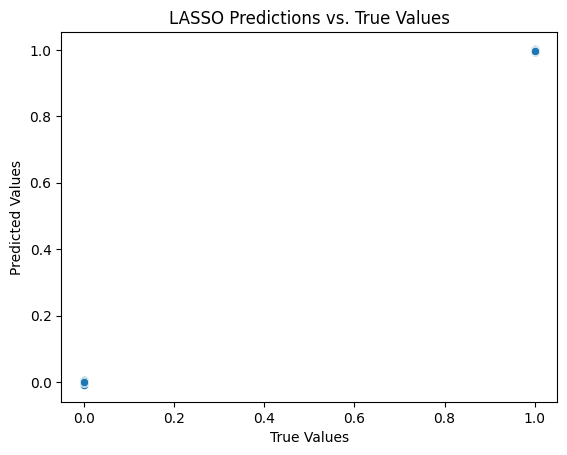

In [ ]:
y_pred = lasso.predict(genes_sc)

sns.scatterplot(x = y, y = y_pred)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('LASSO Predictions vs. True Values')

5. Make a plot that shows the cross validated MSE as α
 varies. For what values of
 is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

Optimal cost hyperparameter: 0.0006701743064744867


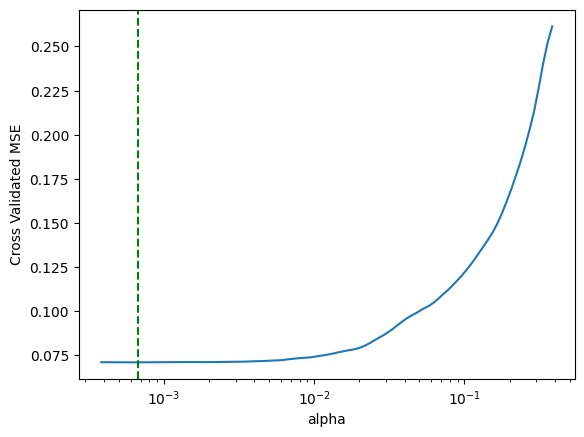

In [ ]:
index_star = np.argmin(np.mean(lasso.mse_path_,axis=1) )
alpha_star = lasso.alphas_[index_star]

sns.lineplot( x=lasso.alphas_, y= np.mean(lasso.mse_path_,axis=1) )
plt.axvline(x=alpha_star, color='green', linestyle='--',
            linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross Validated MSE")
print(f'Optimal cost hyperparameter: {alpha_star}')

The model underfits for alpha values less than 0.00067 and overfits for alpha greather than 0.00067. The hyperparameter which
optimizes the model is 0.00067.

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

The linear regression performs perfectly on the training set because the model was trained on all the data. It already knows everything
in there, so it can correctly predict everything in that same dataset. It is also likely overfitting. LASSO provides better
predictions overall because it optimizes the set of predictors and trains trains the data on only some of the full data set,
meaning it is less likely to overfit and will perform better on new, unseen data.

7. Why do regularization methods lend themselves to scenarios like precision health?

Precision health data sets tend to include many, many different predictor variables. It is computationally expensive (and sometimes
just worse overall) to include all these variables in a model, and regularization is a good way to narrow down which predictors
should actually be used.

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

One risk is that the models aren't always correct. Though they may predict one type of cancer, the pantient could in actuality
have the other type, meaning they would receive the wrong kind of treatment. Another risk is that the models will be used for
more malicious purposes than just detecting cancer for treatment. For example, if health insurance companies got ahold of such
models and required/greatly incentivized genetic testing, they would be able to predict which customers were more likely to get
cancer and then raise insurance prices for them.